<h1><center>LSTM-based MODELS</center></h1>

## I. LIBRARIES

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import os
import datetime
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Conv1D
from keras.layers import MaxPooling1D
from keras.layers import Flatten
from keras.layers import Dropout
from keras.layers import RepeatVector
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

print("Num GPUs Available: ", len(tf.config.list_physical_devices("GPU")))
tf.random.set_seed(8) # fix random seed for reproducibility

Num GPUs Available:  0


## II. HYPERPARAMETERS

In [2]:
# Global param
Y_COL = 0 # the column index (0-based) in the dataset corresponding to the target variable (output)
FEATURE_NUMBER = 1
MODEL_LOCATION = "./Saved Model/New Cleaned"
# Hyperparameter
TRAIN_TEST_RATIO = 0.8
TIME_STEP = 21 # previous time step = 10
# MODEL_TYPE = "LSTM"
MODEL_TYPE = "CNN_LSTM"
EPOCH_SIZE = 1000
BATCH_SIZE = 5
MODEL_JSON = {}
MIN_DELTA = 0.0001
PATIENCE = 15
# X = [41,2,1,1,16,1,1,1,864] # SSO_CNN.txt
CNN_LSTM = [2,2,1,248,257,51,8]
EARLY_STOPPING = tf.keras.callbacks.EarlyStopping(
    monitor="loss",
    min_delta=MIN_DELTA,
    patience=PATIENCE,
    verbose=0,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
)


def to_string():
    print_list = [
        f"Time step: {TIME_STEP}",
        f"Ratio: {TRAIN_TEST_RATIO}",
        f"Model type: {MODEL_TYPE}",
        f"Epoch size: {EPOCH_SIZE}",
        f"Batch size: {BATCH_SIZE}",
        f"Early stop patience: {PATIENCE}, min delta: {MIN_DELTA}",
        f"Model json: {MODEL_JSON}",
    ]
    return "\n".join(print_list)

## III. DATA PRE-PROCESSING

### 3.1. Extract & Clean Data

In [3]:
# Load Data into Dataframe
# Data of year 2021
df1 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 1", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df2 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 2", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL')
df3 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 3", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df4 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 4", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV')
df5 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 5", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df6 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 6", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV')
df7 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 7", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df8 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 8", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df9 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 9", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV')
df10 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 10", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
df11 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 11", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV')
df12 = pd.read_excel('./Data/Cleaned_HC_2021.xlsx', sheet_name="HC THÁNG 12", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')


# Merge many columns of 1 df into one column of that df
df1_melted = pd.melt(df1)
df2_melted = pd.melt(df2)
df3_melted = pd.melt(df3)
df4_melted = pd.melt(df4)
df5_melted = pd.melt(df5)
df6_melted = pd.melt(df6)
df7_melted = pd.melt(df7)
df8_melted = pd.melt(df8)
df9_melted = pd.melt(df9)
df10_melted = pd.melt(df10)
df11_melted = pd.melt(df11)
df12_melted = pd.melt(df12)

# # Data of year 2022
# df2_1 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 1", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
# df2_2 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 2", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL')
# df2_3 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 3", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV, FA')
# df2_4 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 4", skiprows=[0, 1, 2], header=None, usecols='G, L, Q, V, AA, AF, AK, AP, AU, AZ, BE, BJ, BO, BT, BY, CD, CI, CN, CS, CX, DC, DH, DM, DR, DW, EB, EG, EL, EQ, EV')
# df2_5 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 5", skiprows=[0, 1, 2], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC, HJ')
# df2_6 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 6", skiprows=[0, 1, 2], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC')
# df2_7 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 7", skiprows=[0, 1, 2], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC, HJ')
# df2_8 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 8", skiprows=[0, 1, 2], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC, HJ')
# df2_9 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 9", skiprows=[0, 1, 2], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC')
# df2_10 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 10", skiprows=[0, 1, 2], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC, HJ')
# df2_11 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 11", skiprows=[0, 1, 2], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC')
# df2_12 = pd.read_excel('./Data/Cleaned_HC_Du-lieu-Solar-Farm_2022.xlsx', sheet_name="HC THÁNG 12", skiprows=[0, 1, 2], header=None, usecols='H, O, V, AC, AJ, AQ, AX, BE, BL, BS, BZ, CG, CN, CU, DB, DI, DP, DW, ED, EK, ER, EY, FF, FM, FT, GA, GH, GO, GV, HC, HJ')


# # Merge many columns of 1 df into one column of that df
# df2_1_melted = pd.melt(df2_1)
# df2_2_melted = pd.melt(df2_2)
# df2_3_melted = pd.melt(df2_3)
# df2_4_melted = pd.melt(df2_4)
# df2_5_melted = pd.melt(df2_5)
# df2_6_melted = pd.melt(df2_6)
# df2_7_melted = pd.melt(df2_7)
# df2_8_melted = pd.melt(df2_8)
# df2_9_melted = pd.melt(df2_9)
# df2_10_melted = pd.melt(df2_10)
# df2_11_melted = pd.melt(df2_11)
# df2_12_melted = pd.melt(df2_12)

# print(df2_12_melted) #check

In [4]:
# Concatenate all dfs which have been already reshaped above into 1 single df
# Select only the second column from each DataFrame
df1_power_value = df1_melted.iloc[:, 1]
df2_power_value = df2_melted.iloc[:, 1]
df3_power_value = df3_melted.iloc[:, 1]
df4_power_value = df4_melted.iloc[:, 1]
df5_power_value = df5_melted.iloc[:, 1]
df6_power_value = df6_melted.iloc[:, 1]
df7_power_value = df7_melted.iloc[:, 1]
df8_power_value = df8_melted.iloc[:, 1]
df9_power_value = df9_melted.iloc[:, 1]
df10_power_value = df10_melted.iloc[:, 1]
df11_power_value = df11_melted.iloc[:, 1]
df12_power_value = df12_melted.iloc[:, 1]

# df2_1_power_value = df2_1_melted.iloc[:, 1]
# df2_2_power_value = df2_2_melted.iloc[:, 1]
# df2_3_power_value = df2_3_melted.iloc[:, 1]
# df2_4_power_value = df2_4_melted.iloc[:, 1]
# df2_5_power_value = df2_5_melted.iloc[:, 1]
# df2_6_power_value = df2_6_melted.iloc[:, 1]
# df2_7_power_value = df2_7_melted.iloc[:, 1]
# df2_8_power_value = df2_8_melted.iloc[:, 1]
# df2_9_power_value = df2_9_melted.iloc[:, 1]
# df2_10_power_value = df2_10_melted.iloc[:, 1]
# df2_11_power_value = df2_11_melted.iloc[:, 1]
# df2_12_power_value = df2_12_melted.iloc[:, 1]



# Concatenate the selected columns
concatenated_df1 = pd.concat([df1_power_value, df2_power_value, df3_power_value, df4_power_value, df5_power_value, df6_power_value, df7_power_value, df8_power_value, df9_power_value, df10_power_value, df11_power_value, df12_power_value])
# concatenated_df2 = pd.concat([df2_1_power_value, df2_2_power_value, df2_3_power_value, df2_4_power_value, df2_5_power_value, df2_6_power_value, df2_7_power_value, df2_8_power_value, df2_9_power_value, df2_10_power_value, df2_11_power_value, df2_12_power_value])
# concatenated_df = pd.concat([concatenated_df1, concatenated_df2])
concatenated_df = pd.concat([concatenated_df1])

# Convert the concatenated column into a 1-dimensional array as the result of concatenation will already be a pandas Series, which behaves similarly to a 1-dimensional array
concatenated_df_arr = concatenated_df.values.ravel()

print(concatenated_df_arr)
print(len(concatenated_df_arr))

# Specify the path where want to save the Excel file
output_path = "./Data/output_concatenated_df.xlsx"

# Export the DataFrame to Excel
concatenated_df.to_excel(output_path, index=False)  # Set index=False to exclude row numbers

[ 4.6 10.  17.5 ...  8.6  3.5  3.5]
7665


### 3.2. Preprocessing (PDF)

mean 18.32648401826484
std 10.779889491488346
Reject the null hypothesis: Data does not follow a normal distribution.
counts [0.02462657 0.03233575 0.02736761 0.02796721 0.02878096 0.02745327
 0.02916642 0.02732478 0.02291341 0.02372716 0.02449808 0.01914448
 0.01297713]
counts_number [575 755 639 653 672 641 681 638 535 554 572 447 303]
bin_dataset [ 0.1         3.14615385  6.19230769  9.23846154 12.28461538 15.33076923
 18.37692308 21.42307692 24.46923077 27.51538462 30.56153846 33.60769231
 36.65384615 39.7       ]


c:\Users\Nhan Duong\anaconda3\envs\new_kera_env\lib\site-packages\scipy\stats\_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


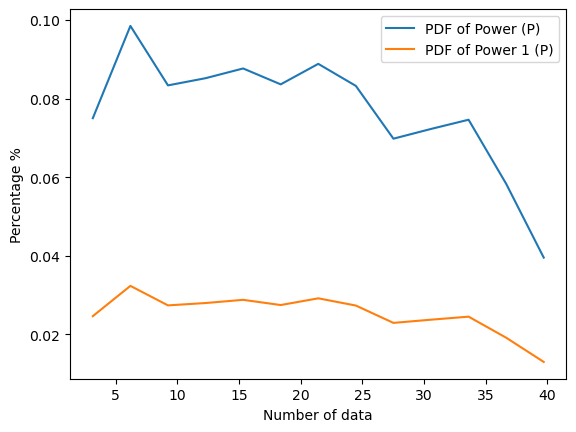

In [5]:
# Preprocessing
dataset = concatenated_df.values.astype("float64")
new_dataset = np.array(np.zeros((1, FEATURE_NUMBER)))
j = 0
mean = np.mean(dataset)
print("mean", mean)
standard_deviation = np.std(dataset)
print("std", standard_deviation)

# Shapiro-Wilk test to determine whether a sample comes from a normal distribution
from scipy.stats import shapiro
statistic, p_value = shapiro(dataset)
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis: Data does not follow a normal distribution.")
else:
    print("Fail to reject the null hypothesis: Data may come from a normal distribution.")

# Check PDF of data
bins_size = int(1 + 3.3 * np.log10(len(dataset)))
counts, bin_dataset = np.histogram(dataset, bins=bins_size, density=True)
counts_number, bin_dataset = np.histogram(dataset, bins=bins_size)
rel_freq = counts_number / len(dataset)
print("counts", counts)
print("counts_number", counts_number)
print("bin_dataset", bin_dataset)
plt.clf()
plt.plot(bin_dataset[1:], rel_freq, label="PDF of Power (P)")
plt.plot(bin_dataset[1:], counts, label="PDF of Power 1 (P)")
plt.xlabel("Number of data")
plt.ylabel("Percentage %")
plt.legend()
plt.show()

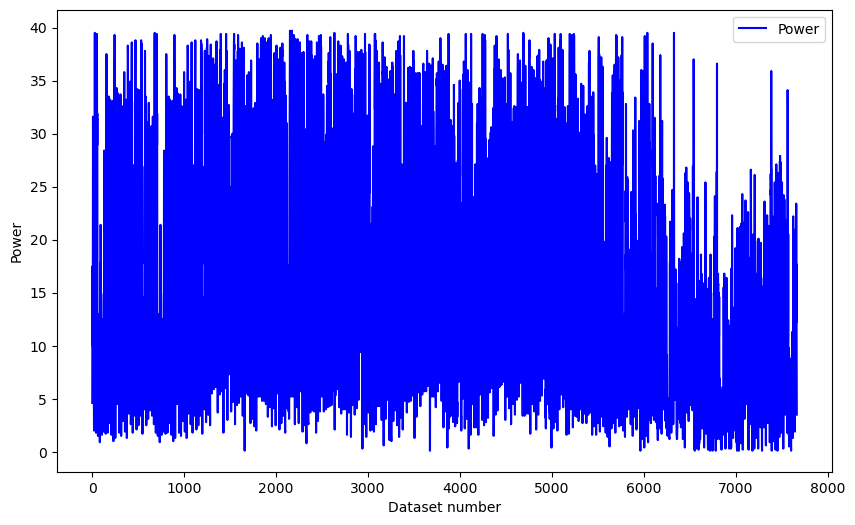

In [6]:
# Plot data (for 1 feature only)
plt.figure(figsize=(10,6))
plt.plot(dataset, color="blue", label="Power")
plt.xlabel("Dataset number")
plt.ylabel("Power")
leg = plt.legend()

# Other features
# plt.twinx()
# plt.ylabel("Temperature")
# plt.plot(dataset[:,0], color="red", label="Temperature")
# leg = plt.legend()
# plt.rcParams.update({'font.size': 10})

plt.show()

### 3.3. Data Split & Normalization

* Split data before normalization to ensure the accuracy
* The MinMaxScaler is used to scale the data to a range between 0 and 1 so that all features are on the same scale. This is important because the LSTM model used for time series prediction is sensitive to the scale of the input data.

In [7]:
# Split into train and test sets
train_size = int(len(dataset) * TRAIN_TEST_RATIO)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size], dataset[train_size:len(dataset)]
print(f"Total : {len(dataset)}, Train: {len(train)}, Test: {len(test)}")
print(train.ndim, test.ndim)

Total : 7665, Train: 6132, Test: 1533
1 1


In [8]:
# Convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-look_back-1):
		a = dataset[i:(i+look_back)]
		dataX.append(a)
		dataY.append(dataset[i + look_back])
	return np.array(dataX), np.array(dataY)

In [9]:
# Create scaler to normalize
scaler = MinMaxScaler(feature_range=(0, 1))
# Normalize x
train_x = scaler.fit_transform(train.reshape(-1, 1))
test_x = scaler.transform(test.reshape(-1, 1))
# Calculate mean and standard deviation for training data x
mean_train_x = np.mean(train_x)
std_train_x = np.std(train_x)
# Calculate mean and standard deviation for testing data x
mean_test_x = np.mean(test_x)
std_test_x = np.std(test_x)
# Standardize training and testing data
train_x_standardized = (train_x - mean_train_x) / std_train_x
test_x_standardized = (test_x - mean_test_x) / std_test_x

# Reshape into X=t and Y=t+TIME_STEP
train_x_standardized, _ = create_dataset(train_x_standardized, TIME_STEP)
test_x_standardized, _ = create_dataset(test_x_standardized, TIME_STEP)
_ , train_y = create_dataset(train, TIME_STEP)
_ , test_y = create_dataset(test, TIME_STEP)

# Normalize y 
train_y = scaler.fit_transform(train_y.reshape(-1,1))
test_y = scaler.transform(test_y.reshape(-1,1))
# Calculate mean and standard deviation for training labels (train_y)
mean_train_y = np.mean(train_y)
std_train_y = np.std(train_y)
# Calculate mean and standard deviation for testing labels (test_y)
mean_test_y = np.mean(test_y)
std_test_y = np.std(test_y)
# Standardize training and testing y
train_y_standardized = (train_y - mean_train_y) / std_train_y
test_y_standardized = (test_y - mean_test_y) / std_test_y


Reject the null hypothesis: Data does not follow a normal distribution.
counts [0.17753504 0.29026118 0.2550989  0.2752655  0.26101673 0.26216583
 0.31881617 0.31651798 0.29095064 0.31542634 0.32628528 0.2550989
 0.17236412]
counts_number [3090 5052 4440 4791 4543 4563 5549 5509 5064 5490 5679 4440 3000]
bin_dataset [-1.87638043 -1.59203123 -1.30768203 -1.02333284 -0.73898364 -0.45463444
 -0.17028525  0.11406395  0.39841315  0.68276234  0.96711154  1.25146074
  1.53580993  1.82015913]


c:\Users\Nhan Duong\anaconda3\envs\new_kera_env\lib\site-packages\scipy\stats\_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


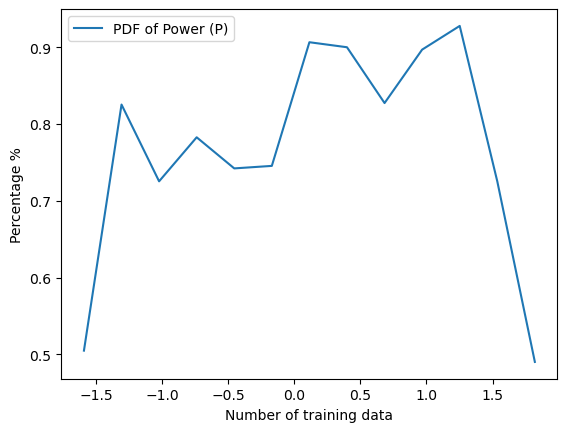

In [10]:
# Shapiro-Wilk test to determine whether a sample comes from a normal distribution
from scipy.stats import shapiro
statistic, p_value = shapiro(train_x_standardized)
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis: Data does not follow a normal distribution.")
else:
    print("Fail to reject the null hypothesis: Data may come from a normal distribution.")

# Check PDF of data after normalization
bins_size = int(1 + 3.3 * np.log10(len(train_x_standardized)))
counts, bin_train_x = np.histogram(train_x_standardized, bins=bins_size, density=True)
counts_number, bin_train_x = np.histogram(train_x_standardized, bins=bins_size)
rel_freq = counts_number / len(train_x_standardized)
print("counts", counts)
print("counts_number", counts_number)
print("bin_dataset", bin_train_x)
plt.clf()
plt.plot(bin_train_x[1:], rel_freq, label="PDF of Power (P)")
plt.xlabel("Number of training data")
plt.ylabel("Percentage %")
plt.legend()
plt.show()

In [11]:
# reshape input to be [samples, time steps, features]
train_x_standardized = np.reshape(train_x_standardized, (train_x_standardized.shape[0], TIME_STEP, FEATURE_NUMBER))
test_x_standardized = np.reshape(test_x_standardized, (test_x_standardized.shape[0], TIME_STEP, FEATURE_NUMBER))

## IV. TRAINING MODELS

Depending on the model type input in the Hyperparameters section at the beginning, it will add different layers for different model types.

In [12]:
# create and fit the network
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
model = Sequential()
if MODEL_TYPE == "CNN": # 
    model.add(
        Conv1D(32, (2), activation="relu", input_shape=(TIME_STEP, FEATURE_NUMBER))
    )
    model.add(Conv1D(16, (2), activation="relu"))
    model.add(Conv1D(8, (1), activation="relu"))
    model.add(MaxPooling1D((2)))
    model.add(Flatten())
    model.add(Dense(64, activation="relu"))
    model.add(Dense(1))
elif MODEL_TYPE == "LSTM":
    # Adds an LSTM layer with 32 units to the model
    model.add(LSTM(32, input_shape=(TIME_STEP, 1), return_sequences=True))
    # Adds another LSTM layer with 32 units to the model
    model.add(LSTM(32, input_shape=(TIME_STEP, 1)))
    # Adds a dense layer with one unit to the model
    model.add(Dense(1)) 
elif MODEL_TYPE == "CNN_LSTM":
    model.add(
        # Set filter size = 3 doesn't give a better result
        Conv1D(6, (2), activation="relu", input_shape=(TIME_STEP, FEATURE_NUMBER))
    )
    # Previous LSTM units = 300 & only 1 layer. Tried 500 but not Test MAPE is higher than when 400
    model.add(LSTM(400, "relu", input_shape=(TIME_STEP, FEATURE_NUMBER), return_sequences=True))
    model.add(LSTM(400, activation="relu"))
    model.add(Dense(1))
elif MODEL_TYPE == "CNN_LSTM_DNN":
    model.add(
        Conv1D(8, (2), activation="relu", input_shape=(TIME_STEP, FEATURE_NUMBER))
    )
    model.add(LSTM(32, "relu", return_sequences=True))
    model.add(LSTM(32, "relu"))
    model.add(Dense(16))
    model.add(Dense(8))
    model.add(Dense(1))
model.summary()
MODEL_JSON = model.to_json()
model.compile(loss="mse", optimizer="adam", metrics=["mse", "mae", "mape"])
history = model.fit(
    train_x_standardized,
    train_y_standardized,
    epochs=EPOCH_SIZE,
    batch_size=BATCH_SIZE,
    verbose=2,
    callbacks=[EARLY_STOPPING, tensorboard_callback],
)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 9, 6)              18        
                                                                 
 lstm (LSTM)                 (None, 9, 400)            651200    
                                                                 
 lstm_1 (LSTM)               (None, 400)               1281600   
                                                                 
 dense (Dense)               (None, 1)                 401       
                                                                 
Total params: 1,933,219
Trainable params: 1,933,219
Non-trainable params: 0
_________________________________________________________________
Epoch 1/1000
1225/1225 - 160s - loss: 0.3980 - mse: 0.3980 - mae: 0.4849 - mape: 247.9045 - 160s/epoch - 131ms/step
Epoch 2/1000
1225/1225 - 150s - loss: 0.2921 - mse: 0.2921 - m

In [13]:
# Save model
version = 0
if not os.path.exists(MODEL_LOCATION):
    os.makedirs(MODEL_LOCATION)
for dir in os.scandir(f"{MODEL_LOCATION}/"):
    if dir.is_dir():
        version = int(dir.name) if int(dir.name) > version else version
version += 1
model.save(f"{MODEL_LOCATION}/{version}")

INFO:tensorflow:Assets written to: ./Saved Model/New Cleaned/10\assets


INFO:tensorflow:Assets written to: ./Saved Model/New Cleaned/10\assets


## V. PREDICTION

1. **RMSE (Root Mean Squared Error):** 
    * Lower RMSE values are generally better. A lower RMSE indicates that your model's predictions are closer to the true values.
    * However, whether a particular RMSE is good or not depends on the scale of your data. 
2. **RMSPE (Root Mean Squared Percentage Error):** usually expressed as a percentage
3. **MAE (Mean Absolute Error):** lower MAE values are better. MAE measures the average magnitude of errors, and a lower MAE indicates that the model's predictions are closer to the true values.
4. **MAPE (Mean Absolute Percentage Error):** the average percentage difference between predictions and their intended targets in the dataset. *The lower the value for MAPE, the better the machine learning model* is at predicting values.

### 5.1. Normal Prediction

[0.49231719970703125, 0.49231719970703125, 0.5252875089645386, 183.91734313964844]
48/48 [==============================] - 1s 29ms/step
Train MSE Score: 0.503418707186457 MSE
Test MSE Score: 25.591448615478935 MSE
Train MAE Score: 0.509976744303092 MAE
Test MAE Score: 3.786720286089188 MAE
Train MAPE Score: 0.0528 MAPE
Test MAPE Score: 0.7683 MAPE
Train RMSE Score: 0.709520054111550 RMSE
Test RMSE Score: 5.058799127804833 RMSE
Train RMSPE: 0.2739 RMSPE
Test RMSPE: 2.1608 RMSPE


<Figure size 640x480 with 0 Axes>

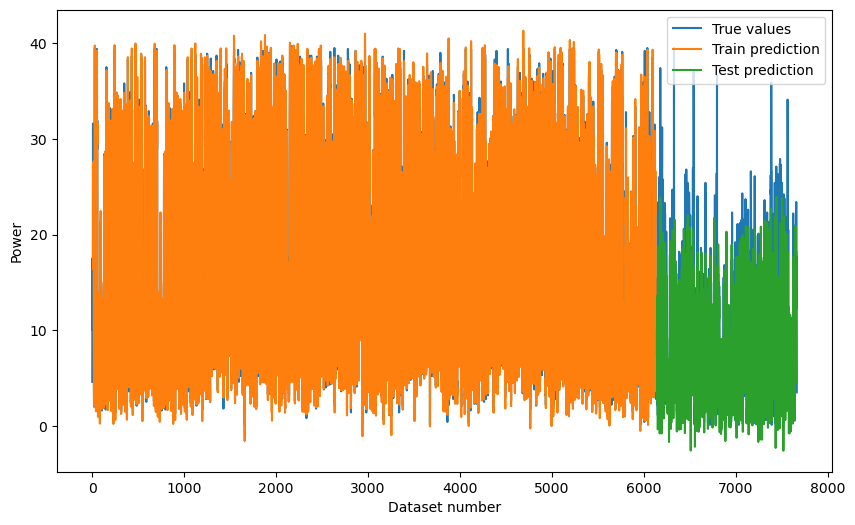

In [14]:
# Predictions
score = model.evaluate(test_x_standardized, test_y_standardized,batch_size=20, verbose=0)  # return MAPE
print(score)

# predict result of train and test for evaluation
train_predict_n_std = model.predict(train_x_standardized)
test_predict_n_std = model.predict(test_x_standardized)

# invert predictions to get value before standardization
train_predict_n = (train_predict_n_std * std_train_x) + mean_train_x
test_predict_n = (test_predict_n_std * std_test_x) + mean_test_x
train_true_n = (train_y_standardized * std_train_y) + mean_train_y
test_true_n = (test_y_standardized * std_test_y) + mean_test_y

# invert predictions to get value before normalize
train_predict = scaler.inverse_transform(train_predict_n)
train_true = scaler.inverse_transform(train_true_n).reshape(1, -1)
test_predict = scaler.inverse_transform(test_predict_n)
test_true = scaler.inverse_transform(test_true_n).reshape(1, -1)

# calculate mean absolute error (MAE)
train_mae = mean_absolute_error(train_true[0], train_predict[:, 0])
test_mae = mean_absolute_error(test_true[0], test_predict[:, 0])
# calculate mean absolute percentage error (MAPE)
train_mape = mean_absolute_percentage_error(train_true[0], train_predict[:, 0])
test_mape = mean_absolute_percentage_error(test_true[0], test_predict[:, 0])
# calculate mean squared error (MSE)
train_mse = mean_squared_error(train_true[0], train_predict[:, 0])
test_mse = mean_squared_error(test_true[0], test_predict[:, 0])
# calculate root mean squared error (RMSE)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
# calculate root mean squared percentage error (RMSPE)
train_rmspe = np.sqrt(
    np.mean(
        np.square(((train_true[0] - train_predict[:, 0]) / train_true[0])),
        axis=0,
    )
)
test_rmspe = np.sqrt(
    np.mean(
        np.square(((test_true[0] - test_predict[:, 0]) / test_true[0])),
        axis=0,
    )
)

train_mse_output = "Train MSE Score: %.15f MSE" % train_mse
test_mse_output = "Test MSE Score: %.15f MSE" % test_mse
train_mae_output = "Train MAE Score: %.15f MAE" % train_mae
test_mae_output = "Test MAE Score: %.15f MAE" % test_mae
train_mape_output = "Train MAPE Score: %.4f MAPE" % train_mape
test_mape_output = "Test MAPE Score: %.4f MAPE" % test_mape
train_rmse_output = "Train RMSE Score: %.15f RMSE" % train_rmse
test_rmse_output = "Test RMSE Score: %.15f RMSE" % test_rmse
train_rmspe_output = "Train RMSPE: %.4f RMSPE" % train_rmspe
test_rmspe_output = "Test RMSPE: %.4f RMSPE" % test_rmspe
print(train_mse_output)
print(test_mse_output)
print(train_mae_output)
print(test_mae_output)
print(train_mape_output)
print(test_mape_output)
print(train_rmse_output)
print(test_rmse_output)
print(train_rmspe_output)
print(test_rmspe_output)

rmse_file = open(f"./{MODEL_LOCATION}/{version}/info.md", "w")
rmse_file.write(
    train_mse_output
    + "\n"
    + test_mse_output
    + "\n"
    + train_mae_output
    + "\n"
    + test_mae_output
    + "\n"
    + train_mape_output
    + "\n"
    + test_mape_output
    + "\n"
    + train_rmse_output
    + "\n"
    + test_rmse_output
    + "\n"
    + train_rmspe_output
    + "\n"
    + test_rmspe_output
)
# shift train predictions for plotting
trainPredictPlot = np.empty_like(dataset).reshape(-1, 1)
trainPredictPlot[:] = np.nan
trainPredictPlot[TIME_STEP : len(train_predict) + TIME_STEP] = train_predict
# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset).reshape(-1, 1)
testPredictPlot[:] = np.nan
testPredictPlot[
    len(train_predict) + (TIME_STEP * 2) + 1 : len(dataset) - 1
] = test_predict

true_values = (dataset).reshape(-1, 1)
# plot baseline and predictions
plt.clf()
plt.figure(figsize=(10, 6))
plt.rcParams.update({"font.size": 10})
plt.xlabel("Dataset number")
plt.ylabel("Power")
plt.plot(true_values, label="True values")
# plt.plot(test_true.reshape(-1,1), label="Test true")
plt.plot(trainPredictPlot, label="Train prediction")
plt.plot(testPredictPlot, label="Test prediction")
leg = plt.legend()

plt.savefig(f"{MODEL_LOCATION}/{version}/predict_normal.png")
plt.show()

### 5.2. Cumulative Prediction

In [15]:
# Getting prediction for cumulative result
train_predict_n_std = model.predict(train_x_standardized)
test_predict_n_std = model.predict(test_x_standardized)

# invert predictions to get value before standardization
train_predict_n = (train_predict_n_std * std_train_x) + mean_train_x
test_predict_n = (test_predict_n_std * std_test_x) + mean_test_x
train_true_n = (train_y_standardized * std_train_y) + mean_train_y
test_true_n = (test_y_standardized * std_test_y) + mean_test_y

# invert predictions to get value before normalize
train_predict = scaler.inverse_transform(train_predict_n)
train_true = scaler.inverse_transform(train_y).reshape(1, -1)
test_predict = scaler.inverse_transform(test_predict_n)
test_true = scaler.inverse_transform(test_y).reshape(1, -1)

# get cumulative train and test predictions
true_values = np.cumsum((dataset).reshape(-1,1))
train_true = np.cumsum(train_true).reshape(1, -1)
test_true = true_values[-len(test_true[0]):].reshape(1,-1)

train_predict = np.cumsum(train_predict).reshape(-1, 1)
test_predict = np.cumsum(np.append(test_true[0, 0], test_predict))[1:].reshape(-1, 1)

# calculate mean absolute error (MAE)
train_mae = mean_absolute_error(train_true[0], train_predict[:, 0])
test_mae = mean_absolute_error(test_true[0], test_predict[:, 0])
# calculate mean absolute percentage error (MAPE)
train_mape = mean_absolute_percentage_error(train_true[0], train_predict[:, 0])
test_mape = mean_absolute_percentage_error(test_true[0], test_predict[:, 0])
# calculate mean squared error (MSE)
train_mse = mean_squared_error(train_true[0], train_predict[:, 0])
test_mse = mean_squared_error(test_true[0], test_predict[:, 0])
# calculate root mean squared error (RMSE)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
# calculate root mean squared percentage error (RMSPE)
train_rmspe = np.sqrt(
    np.mean(
        np.square(((train_true[0] - train_predict[:, 0]) / train_true[0])),
        axis=0,
    )
)
test_rmspe = np.sqrt(
    np.mean(
        np.square(((test_true[0] - test_predict[:, 0]) / test_true[0])),
        axis=0,
    )
)

train_mse_output = "Train MSE Score: %.15f MSE" % train_mse
test_mse_output = "Test MSE Score: %.15f MSE" % test_mse
train_mae_output = "Train MAE Score: %.15f MAE" % train_mae
test_mae_output = "Test MAE Score: %.15f MAE" % test_mae
train_mape_output = "Train MAPE Score: %.4f MAPE" % train_mape
test_mape_output = "Test MAPE Score: %.4f MAPE" % test_mape
train_rmse_output = "Train RMSE Score: %.15f RMSE" % train_rmse
test_rmse_output = "Test RMSE Score: %.15f RMSE" % test_rmse
train_rmspe_output = "Train RMSPE: %.4f RMSPE" % train_rmspe
test_rmspe_output = "Test RMSPE: %.4f RMSPE" % test_rmspe
print(train_mse_output)
print(test_mse_output)
print(train_mae_output)
print(test_mae_output)
print(train_mape_output)
print(test_mape_output)
print(train_rmse_output)
print(test_rmse_output)
print(train_rmspe_output)
print(test_rmspe_output)

rmse_file = open(f"./{MODEL_LOCATION}/{version}/info.md", "a")
rmse_file.write(
    "\n\nCumulative:\n"
    + train_mse_output
    + "\n"
    + test_mse_output
    + "\n"
    + train_mae_output
    + "\n"
    + test_mae_output
    + "\n"
    + train_mape_output
    + "\n"
    + test_mape_output
    + "\n"
    + train_rmse_output
    + "\n"
    + test_rmse_output
    + "\n"
    + train_rmspe_output
    + "\n"
    + test_rmspe_output
    + "\n\n"
    + to_string()
)
rmse_file.close()

48/48 [==============================] - 1s 28ms/step
Train MSE Score: 42357.614051126001868 MSE
Test MSE Score: 940031.837367074913345 MSE
Train MAE Score: 169.431019089412615 MAE
Test MAE Score: 875.638571315667718 MAE
Train MAPE Score: 0.0025 MAPE
Test MAPE Score: 0.0065 MAPE
Train RMSE Score: 205.809654902596833 RMSE
Test RMSE Score: 969.552390212656292 RMSE
Train RMSPE: 0.0026 RMSPE
Test RMSPE: 0.0072 RMSPE


In [16]:
# Getting prediction for cumulative result
train_predict_cum_n_std = model.predict(train_x_standardized)
test_predict_cum_n_std = model.predict(test_x_standardized)

# invert predictions to get value before standardization
train_predict_cum_n = (train_predict_cum_n_std * std_train_x) + mean_train_x
test_predict_cum_n = (test_predict_cum_n_std * std_test_x) + mean_test_x
train_true_cum_n = (train_y_standardized * std_train_y) + mean_train_y
test_true_cum_n = (test_y_standardized * std_test_y) + mean_test_y

# invert predictions to get value before normalize
train_predict_cum = scaler.inverse_transform(train_predict_cum_n)
train_true_cum = scaler.inverse_transform(train_true_cum_n).reshape(1, -1)
test_predict_cum = scaler.inverse_transform(test_predict_cum_n)
test_true_cum = scaler.inverse_transform(test_true_cum_n).reshape(1, -1)

# get cumulative train and test predictions
true_values = np.cumsum((dataset).reshape(-1,1))
train_true_cum = np.cumsum(train_true_cum).reshape(1, -1)
test_true_cum = true_values[-len(test_true_cum[0]):].reshape(1,-1)

train_true_cum = np.cumsum(train_true_cum).reshape(-1, 1)
test_true_cum = np.cumsum(np.append(test_true_cum[0, 0], test_predict_cum))[1:].reshape(-1, 1)

# reshape train_predict_cum & test_predict_cum to match shape with train/test_true_cum
train_predict_cum = train_predict_cum.reshape(-1, 1)
test_predict_cum = test_predict_cum.reshape(-1, 1)

# calculate mean absolute error (MAE)
train_mae = mean_absolute_error(train_true_cum[0], train_predict_cum[0])
test_mae = mean_absolute_error(test_true_cum[0], test_predict_cum[0])
# calculate mean absolute percentage error (MAPE)
train_mape = mean_absolute_percentage_error(train_true_cum[0], train_predict_cum[0])
test_mape = mean_absolute_percentage_error(test_true_cum[0], test_predict_cum[0])
# calculate mean squared error (MSE)
train_mse = mean_squared_error(train_true_cum[0], train_predict_cum[0])
test_mse = mean_squared_error(test_true_cum[0], test_predict_cum[0])
# calculate root mean squared error (RMSE)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
# calculate root mean squared percentage error (RMSPE)
train_rmspe = np.sqrt(
    np.mean(
        np.square(((train_true_cum[0] - train_predict_cum[0]) / train_true_cum[0])),
        axis=0,
    )
)
test_rmspe = np.sqrt(
    np.mean(
        np.square(((test_true_cum[0] - test_predict_cum[0]) / test_true_cum[0])),
        axis=0,
    )
)

train_mse_output = "Train MSE Score: %.15f MSE" % train_mse
test_mse_output = "Test MSE Score: %.15f MSE" % test_mse
train_mae_output = "Train MAE Score: %.15f MAE" % train_mae
test_mae_output = "Test MAE Score: %.15f MAE" % test_mae
train_mape_output = "Train MAPE Score: %.4f MAPE" % train_mape
test_mape_output = "Test MAPE Score: %.4f MAPE" % test_mape
train_rmse_output = "Train RMSE Score: %.15f RMSE" % train_rmse
test_rmse_output = "Test RMSE Score: %.15f RMSE" % test_rmse
train_rmspe_output = "Train RMSPE: %.4f RMSPE" % train_rmspe
test_rmspe_output = "Test RMSPE: %.4f RMSPE" % test_rmspe
print(train_mse_output)
print(test_mse_output)
print(train_mae_output)
print(test_mae_output)
print(train_mape_output)
print(test_mape_output)
print(train_rmse_output)
print(test_rmse_output)
print(train_rmspe_output)
print(test_rmspe_output)

rmse_file = open(f"./{MODEL_LOCATION}/{version}/info.md", "a")
rmse_file.write(
    "\n\nCumulative:\n"
    + train_mse_output
    + "\n"
    + test_mse_output
    + "\n"
    + train_mae_output
    + "\n"
    + test_mae_output
    + "\n"
    + train_mape_output
    + "\n"
    + test_mape_output
    + "\n"
    + train_rmse_output
    + "\n"
    + test_rmse_output
    + "\n"
    + train_rmspe_output
    + "\n"
    + test_rmspe_output
    + "\n\n"
    + to_string()
)
rmse_file.close()

48/48 [==============================] - 1s 27ms/step
Train MSE Score: 0.038153529448901 MSE
Test MSE Score: 15363825610.809959411621094 MSE
Train MAE Score: 0.195329284667970 MAE
Test MAE Score: 123950.899999999834108 MAE
Train MAPE Score: 0.0102 MAPE
Test MAPE Score: 0.9999 MAPE
Train RMSE Score: 0.195329284667970 RMSE
Test RMSE Score: 123950.899999999834108 RMSE
Train RMSPE: 0.0102 RMSPE
Test RMSPE: 0.9999 RMSPE


(7665,)
(7665, 1)


<Figure size 640x480 with 0 Axes>

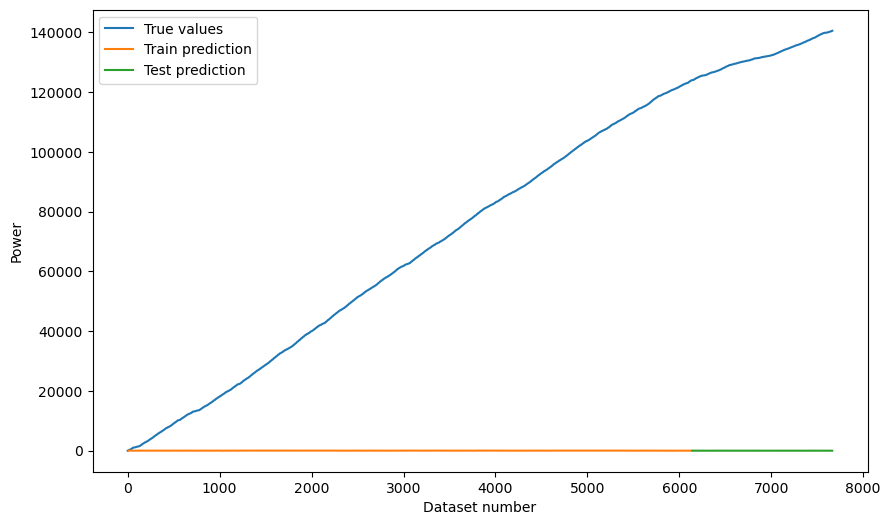

In [17]:
# Plotting for cumulative
# shift train predictions for plotting
trainPredictPlot = np.empty_like(dataset).reshape(-1,1)
trainPredictPlot[:] = np.nan
trainPredictPlot[TIME_STEP:len(train_predict_cum)+TIME_STEP] = train_predict_cum
# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset).reshape(-1,1)
testPredictPlot[:] = np.nan
testPredictPlot[
    len(train_predict_cum) + (TIME_STEP * 2) + 1 : len(dataset) - 1
] = test_predict_cum

true_values = np.cumsum((dataset).reshape(-1,1))
print(true_values.shape)
print(trainPredictPlot.shape)
# plot baseline and predictions
plt.clf()
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 10})
plt.xlabel("Dataset number")
plt.ylabel("Power")
plt.plot(true_values, label="True values")
# plt.plot(test_true.reshape(-1,1), label="Test true")
plt.plot(trainPredictPlot, label="Train prediction")
plt.plot(testPredictPlot, label="Test prediction")
leg = plt.legend()

plt.savefig(f"{MODEL_LOCATION}/{version}/predict_cumulative.png")
plt.show()

(7665,)
(7665, 1)


<Figure size 640x480 with 0 Axes>

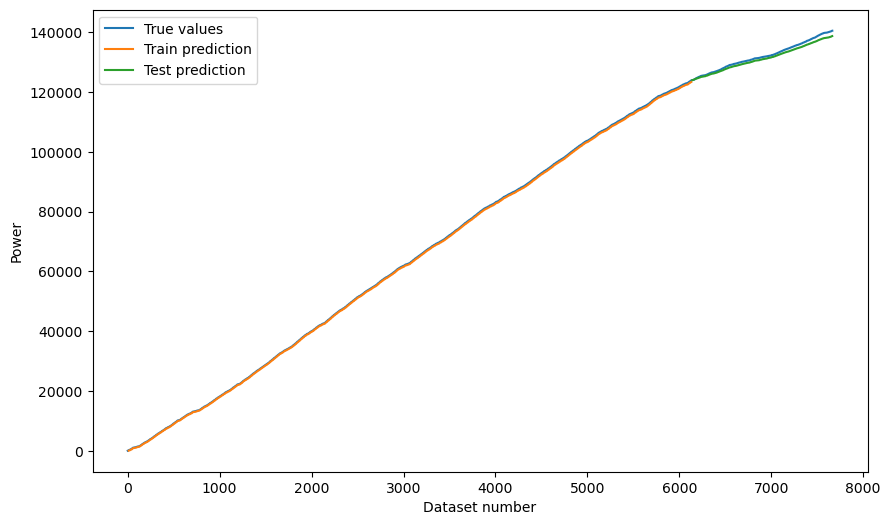

In [18]:
# Plotting for cumulative
# shift train predictions for plotting
trainPredictPlot = np.empty_like(dataset).reshape(-1,1)
trainPredictPlot[:] = np.nan
trainPredictPlot[TIME_STEP:len(train_predict)+TIME_STEP] = train_predict
# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset).reshape(-1,1)
testPredictPlot[:] = np.nan
testPredictPlot[
    len(train_predict) + (TIME_STEP * 2) + 1 : len(dataset) - 1
] = test_predict

true_values = np.cumsum((dataset).reshape(-1,1))
print(true_values.shape)
print(trainPredictPlot.shape)
# plot baseline and predictions
plt.clf()
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 10})
plt.xlabel("Dataset number")
plt.ylabel("Power")
plt.plot(true_values, label="True values")
# plt.plot(test_true.reshape(-1,1), label="Test true")
plt.plot(trainPredictPlot, label="Train prediction")
plt.plot(testPredictPlot, label="Test prediction")
leg = plt.legend()

plt.savefig(f"{MODEL_LOCATION}/{version}/predict_cumulative.png")
plt.show()